# Normalisasi Min-Max Probabilitas Hujan vs ONI per Musim
**Wilayah:** Nusa Tenggara Timur (NTT)  
**Periode:** 1985–2015  
**Sumber:** Data spasial probabilitas hujan & Indeks ONI (NOAA)

> Probabilitas hujan dan indeks ONI dinormalisasi ke skala **0–1** menggunakan Min-Max Scaling  
> agar dapat dibandingkan dalam satu sumbu meski satuan aslinya berbeda (prob.hujan: 0–100%, ONI: −3 s/d +3).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')


In [2]:
# ── Gaya PPKI IPB ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family'      : 'Times New Roman',
    'font.size'        : 11,
    'axes.titlesize'   : 12,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 11,
    'axes.labelweight' : 'bold',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : False,       # tanpa gridline
    'xtick.direction'  : 'out',
    'ytick.direction'  : 'out',
    'figure.dpi'       : 150,
    'savefig.dpi'      : 300,
    'savefig.bbox'     : 'tight',
})

SEASON_ORDER  = ['JFM', 'AMJ', 'JAS', 'OND']
SEASON_MONTHS = {'JFM': 'Jan–Mar', 'AMJ': 'Apr–Jun',
                 'JAS': 'Jul–Sep', 'OND': 'Okt–Des'}
SEASON_COLORS = {'JFM': '#3b82f6', 'AMJ': '#22c55e',
                 'JAS': '#eab308', 'OND': '#ec4899'}


In [3]:
# ── Load Data ─────────────────────────────────────────────────────────────
import os

def load_spasial(path='spasial_data.csv'):
    if os.path.exists(path):
        df = pd.read_csv(path)
        df.columns = df.columns.str.strip()
        for c in df.columns:
            if c.lower() in ('season','musim'):  df.rename(columns={c:'Season'}, inplace=True)
            if c.lower() in ('hujan','rain','prob','probability'): df.rename(columns={c:'Hujan'}, inplace=True)
        df['Season'] = df['Season'].str.upper().str.strip()
        return df
    # simulasi
    rng = np.random.default_rng(42)
    lats = np.linspace(-12, -7, 25); lons = np.linspace(118, 126, 25)
    rows = []
    for y in range(1985, 2016):
        for s in SEASON_ORDER:
            for la in lats:
                for lo in lons:
                    base = 40 + 30*np.sin(np.radians((lo-118)*20))
                    rows.append({'Year':y,'Season':s,'latitude':la,'longitude':lo,
                                 'Hujan':float(np.clip(base+rng.normal(0,15),0,100))})
    return pd.DataFrame(rows)

def load_oni(path='ONI.csv'):
    if os.path.exists(path):
        df = pd.read_csv(path); df.columns = df.columns.str.strip()
        df = df[(df['Year']>=1985)&(df['Year']<=2015)]
        return df[[c for c in ['Year','JFM','AMJ','JAS','OND'] if c in df.columns]]
    rng = np.random.default_rng(7); years = np.arange(1985,2016)
    return pd.DataFrame({'Year':years,
        'JFM':rng.normal(0,.7,len(years)),'AMJ':rng.normal(0,.7,len(years)),
        'JAS':rng.normal(0,.7,len(years)),'OND':rng.normal(0,.7,len(years))})

spasial = load_spasial()
oni     = load_oni()
print(f"spasial: {spasial.shape}  |  oni: {oni.shape}")


spasial: (57660, 5)  |  oni: (31, 5)


In [4]:
# ── Normalisasi Min-Max ────────────────────────────────────────────────────
def build_norm_df(spasial, oni):
    ts = (spasial.groupby(['Year','Season'])['Hujan'].mean().reset_index()
          .pivot(index='Year', columns='Season', values='Hujan')
          .reindex(columns=SEASON_ORDER).reset_index())
    ch_rename = {s: f'CH_{s}' for s in SEASON_ORDER if s in ts.columns}
    ts = ts.rename(columns=ch_rename)
    gabung = ts.merge(oni, on='Year', how='inner')
    cols_norm = ([f'CH_{s}' for s in SEASON_ORDER if f'CH_{s}' in gabung.columns] +
                 [s for s in SEASON_ORDER if s in gabung.columns])
    gabung_norm = gabung.copy()
    if cols_norm:
        gabung_norm[cols_norm] = MinMaxScaler().fit_transform(gabung[cols_norm])
    return gabung_norm

norm_df = build_norm_df(spasial, oni)
norm_df.head()


,Year,CH_JFM,CH_AMJ,CH_JAS,CH_OND,JFM,AMJ,JAS,OND
0,1985,0.265099,0.500038,0.316177,0.527096,0.21875,0.105263,0.275862,0.375
1,1986,0.780832,0.593412,0.761409,0.401351,0.31250,0.421053,0.551724,0.675
2,1987,0.401085,0.412631,0.387164,0.576130,0.81250,0.947368,0.965517,0.725
3,1988,0.506854,0.000000,0.283392,0.690542,0.59375,0.052632,0.034483,0.000
4,1989,0.673960,0.677193,0.310273,0.187200,0.00000,0.157895,0.310345,0.375


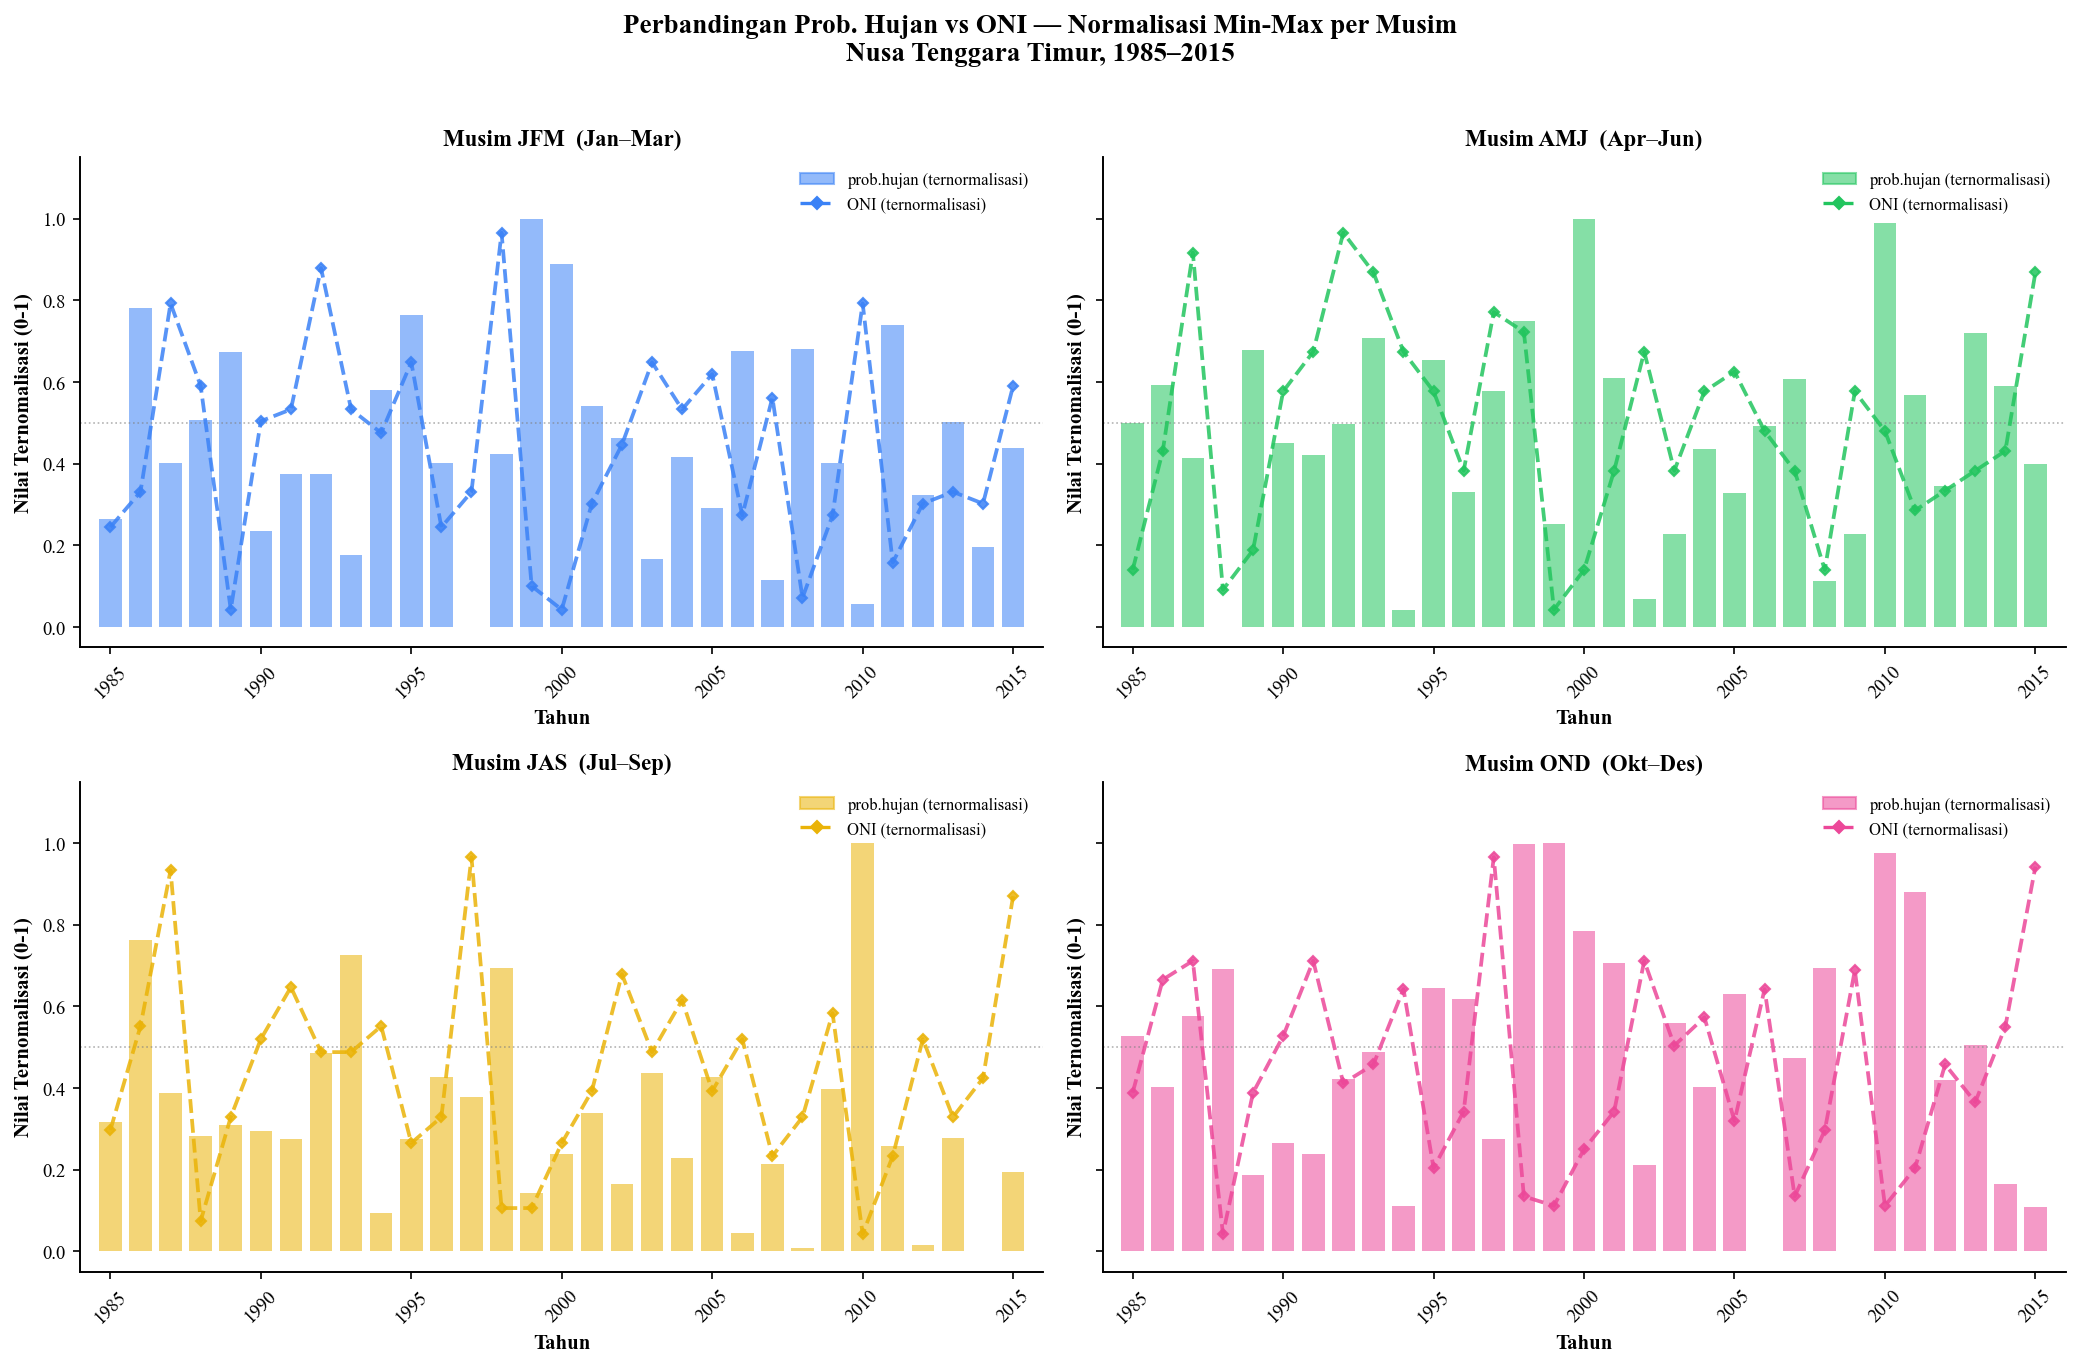

Gambar disimpan: normalisasi_minmax_ppki.png


In [13]:
# ── Visualisasi 4 Musim dalam 1 Frame (2×2) ───────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=True)
axes_flat = axes.flatten()
years = norm_df['Year'].values

for idx, s in enumerate(SEASON_ORDER):
    ax  = axes_flat[idx]
    col = SEASON_COLORS[s]

    if f'CH_{s}' not in norm_df.columns or s not in norm_df.columns:
        ax.set_visible(False)
        continue

    ch_vals  = norm_df[f'CH_{s}'].values
    oni_vals = norm_df[s].values

    # Bar: prob.hujan (ternormalisasi)
    ax.bar(years, ch_vals, color=col, alpha=0.55, width=0.75,
           label='prob.hujan (ternormalisasi.)', linewidth=0)

    # Line: ONI (ternormalisasi)
    ax2 = ax.twinx()
    ax2.plot(years, oni_vals, color=col, linewidth=1.8,
             linestyle='--', marker='D', markersize=3.5,
             alpha=0.85, label='ONI (ternorm.)')
    ax2.set_ylim(-0.1, 1.2)
    ax2.set_yticks([])
    ax2.tick_params(axis='y', labelsize=9)
    ax2.spines['top'].set_visible(False)

    # Garis tengah 0.5
    ax.axhline(0.5, color='gray', linewidth=0.8, linestyle=':', alpha=0.6)

    # Kosmetik panel
    ax.set_title(f'Musim {s}  ({SEASON_MONTHS[s]})', fontweight='bold', fontsize=11)
    ax.set_xlabel('Tahun', fontsize=10)
    ax.set_ylabel('Nilai Ternomalisasi (0-1)', fontsize=10)
    ax.set_xlim(1984, 2016)
    ax.set_ylim(-0.05, 1.15)
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.tick_params(axis='y', labelsize=9)

    # Legenda per panel
    bar_patch = mpatches.Patch(color=col, alpha=0.55, label='prob.hujan (ternormalisasi)')
    line_obj  = Line2D([0],[0], color=col, linewidth=1.6, linestyle='--',
                       marker='D', markersize=4, label='ONI (ternormalisasi)')
    ax.legend(handles=[bar_patch, line_obj], fontsize=8,
              loc='upper right', frameon=False)

# Judul utama (gaya PPKI IPB)
fig.suptitle(
    'Perbandingan Prob. Hujan vs ONI — Normalisasi Min-Max per Musim\n'
    'Nusa Tenggara Timur, 1985–2015',
    fontsize=13, fontweight='bold', y=1.01
)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.savefig('normalisasi_minmax_ppki.png', dpi=1200, bbox_inches='tight')
plt.show()
print("Gambar disimpan: normalisasi_minmax_ppki.png")
